In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import scipy.stats as stats

In [2]:
loan=pd.read_csv(r"E:\Data Science 360\Data scinece\Project\Project Python\Basic Statistics - Hypothesis Testing\4. Basic Statistics - Hypothesis Testing\LoansData.csv")

In [3]:
loan.describe()

,Amount.Requested,Amount.Funded.By.Investors,Monthly.Income,Open.CREDIT.Lines,Revolving.CREDIT.Balance,Inquiries.in.the.Last.6.Months
count,2499.000000,2499.000000,2499.000000,2497.000000,2497.000000,2497.000000
mean,12405.462185,12002.374186,5688.931321,10.072887,15223.184622,0.906688
std,7802.933666,7746.767348,3963.118185,4.507416,18281.015258,1.231149
min,1000.000000,-0.010000,588.500000,2.000000,0.000000,0.000000
25%,6000.000000,6000.000000,3500.000000,7.000000,5584.000000,0.000000
50%,10000.000000,10000.000000,5000.000000,9.000000,10948.000000,0.000000
75%,17000.000000,16000.000000,6800.000000,13.000000,18861.000000,1.000000
max,35000.000000,35000.000000,102750.000000,38.000000,270800.000000,9.000000


In [4]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Amount.Requested                2499 non-null   float64
 1   Amount.Funded.By.Investors      2499 non-null   float64
 2   Interest.Rate                   2498 non-null   object 
 3   Loan.Length                     2500 non-null   object 
 4   Loan.Purpose                    2500 non-null   object 
 5   Debt.To.Income.Ratio            2499 non-null   object 
 6   State                           2500 non-null   object 
 7   Home.Ownership                  2499 non-null   object 
 8   Monthly.Income                  2499 non-null   float64
 9   FICO.Range                      2498 non-null   object 
 10  Open.CREDIT.Lines               2497 non-null   float64
 11  Revolving.CREDIT.Balance        2497 non-null   float64
 12  Inquiries.in.the.Last.6.Months  24

In [5]:
loan.isnull().sum() 

Amount.Requested                   1
Amount.Funded.By.Investors         1
Interest.Rate                      2
Loan.Length                        0
Loan.Purpose                       0
Debt.To.Income.Ratio               1
State                              0
Home.Ownership                     1
Monthly.Income                     1
FICO.Range                         2
Open.CREDIT.Lines                  3
Revolving.CREDIT.Balance           3
Inquiries.in.the.Last.6.Months     3
Employment.Length                 77
dtype: int64

In [6]:
loan.dropna(inplace=True)

In [7]:
loan.isnull().sum()


Amount.Requested                  0
Amount.Funded.By.Investors        0
Interest.Rate                     0
Loan.Length                       0
Loan.Purpose                      0
Debt.To.Income.Ratio              0
State                             0
Home.Ownership                    0
Monthly.Income                    0
FICO.Range                        0
Open.CREDIT.Lines                 0
Revolving.CREDIT.Balance          0
Inquiries.in.the.Last.6.Months    0
Employment.Length                 0
dtype: int64

In [8]:
loan.drop_duplicates(inplace=True)

In [9]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2413 entries, 0 to 2499
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Amount.Requested                2413 non-null   float64
 1   Amount.Funded.By.Investors      2413 non-null   float64
 2   Interest.Rate                   2413 non-null   object 
 3   Loan.Length                     2413 non-null   object 
 4   Loan.Purpose                    2413 non-null   object 
 5   Debt.To.Income.Ratio            2413 non-null   object 
 6   State                           2413 non-null   object 
 7   Home.Ownership                  2413 non-null   object 
 8   Monthly.Income                  2413 non-null   float64
 9   FICO.Range                      2413 non-null   object 
 10  Open.CREDIT.Lines               2413 non-null   float64
 11  Revolving.CREDIT.Balance        2413 non-null   float64
 12  Inquiries.in.the.Last.6.Months  2413 no

In [10]:
# alpha=0.05

In [11]:
loan

,Amount.Requested,Amount.Funded.By.Investors,Interest.Rate,Loan.Length,Loan.Purpose,Debt.To.Income.Ratio,State,Home.Ownership,Monthly.Income,FICO.Range,Open.CREDIT.Lines,Revolving.CREDIT.Balance,Inquiries.in.the.Last.6.Months,Employment.Length
0,20000.0,20000.00,8.90%,36 months,debt_consolidation,14.90%,SC,MORTGAGE,6541.67,735-739,14.0,14272.0,2.0,< 1 year
1,19200.0,19200.00,12.12%,36 months,debt_consolidation,28.36%,TX,MORTGAGE,4583.33,715-719,12.0,11140.0,1.0,2 years
2,35000.0,35000.00,21.98%,60 months,debt_consolidation,23.81%,CA,MORTGAGE,11500.00,690-694,14.0,21977.0,1.0,2 years
3,10000.0,9975.00,9.99%,36 months,debt_consolidation,14.30%,KS,MORTGAGE,3833.33,695-699,10.0,9346.0,0.0,5 years
4,12000.0,12000.00,11.71%,36 months,credit_card,18.78%,NJ,RENT,3195.00,695-699,11.0,14469.0,0.0,9 years
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,30000.0,29950.00,16.77%,60 months,debt_consolidation,19.23%,NY,MORTGAGE,9250.00,705-709,15.0,45880.0,1.0,8 years
2496,16000.0,16000.00,14.09%,60 months,home_improvement,21.54%,MD,OWN,8903.25,740-744,18.0,18898.0,1.0,10+ years
2497,10000.0,10000.00,13.99%,36 months,debt_consolidation,4.89%,PA,MORTGAGE,2166.67,680-684,4.0,4544.0,0.0,10+ years
2498,6000.0,6000.00,12.42%,36 months,major_purchase,16.66%,NJ,RENT,3500.00,675-679,8.0,7753.0,0.0,5 years


In [12]:
loan['Interest.Rate']=loan['Interest.Rate'].str.replace('%','').astype(float)

In [13]:
stats.pearsonr(loan['Amount.Funded.By.Investors'],loan['Interest.Rate'])
#based on this test, higher loan amounts are associated with higher interest rates , pvalue is very low so we reject null hypothesis

PearsonRResult(statistic=0.3315955311036452, pvalue=5.064256950495823e-63)

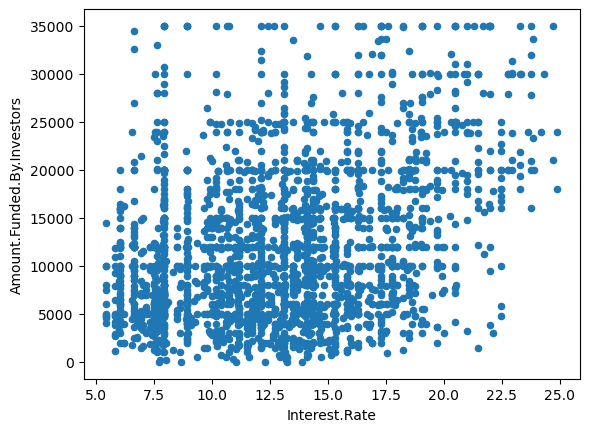

In [14]:
loan.plot(kind='scatter',x='Interest.Rate',y='Amount.Funded.By.Investors')
plt.show()

In [15]:
loan

,Amount.Requested,Amount.Funded.By.Investors,Interest.Rate,Loan.Length,Loan.Purpose,Debt.To.Income.Ratio,State,Home.Ownership,Monthly.Income,FICO.Range,Open.CREDIT.Lines,Revolving.CREDIT.Balance,Inquiries.in.the.Last.6.Months,Employment.Length
0,20000.0,20000.00,8.90,36 months,debt_consolidation,14.90%,SC,MORTGAGE,6541.67,735-739,14.0,14272.0,2.0,< 1 year
1,19200.0,19200.00,12.12,36 months,debt_consolidation,28.36%,TX,MORTGAGE,4583.33,715-719,12.0,11140.0,1.0,2 years
2,35000.0,35000.00,21.98,60 months,debt_consolidation,23.81%,CA,MORTGAGE,11500.00,690-694,14.0,21977.0,1.0,2 years
3,10000.0,9975.00,9.99,36 months,debt_consolidation,14.30%,KS,MORTGAGE,3833.33,695-699,10.0,9346.0,0.0,5 years
4,12000.0,12000.00,11.71,36 months,credit_card,18.78%,NJ,RENT,3195.00,695-699,11.0,14469.0,0.0,9 years
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,30000.0,29950.00,16.77,60 months,debt_consolidation,19.23%,NY,MORTGAGE,9250.00,705-709,15.0,45880.0,1.0,8 years
2496,16000.0,16000.00,14.09,60 months,home_improvement,21.54%,MD,OWN,8903.25,740-744,18.0,18898.0,1.0,10+ years
2497,10000.0,10000.00,13.99,36 months,debt_consolidation,4.89%,PA,MORTGAGE,2166.67,680-684,4.0,4544.0,0.0,10+ years
2498,6000.0,6000.00,12.42,36 months,major_purchase,16.66%,NJ,RENT,3500.00,675-679,8.0,7753.0,0.0,5 years


In [16]:
loan['Loan.Length']=loan['Loan.Length'].str.replace('months','')
loan['Loan.Length']=loan['Loan.Length'].str.replace('s','').astype(int)

In [17]:
stats.pearsonr(loan['Loan.Length'],loan['Interest.Rate'])
#positive linear relationship , reject null hypothesis , loan length increases interest rate

PearsonRResult(statistic=0.42505738230947654, pvalue=1.793801067341337e-106)

In [18]:
loan

,Amount.Requested,Amount.Funded.By.Investors,Interest.Rate,Loan.Length,Loan.Purpose,Debt.To.Income.Ratio,State,Home.Ownership,Monthly.Income,FICO.Range,Open.CREDIT.Lines,Revolving.CREDIT.Balance,Inquiries.in.the.Last.6.Months,Employment.Length
0,20000.0,20000.00,8.90,36,debt_consolidation,14.90%,SC,MORTGAGE,6541.67,735-739,14.0,14272.0,2.0,< 1 year
1,19200.0,19200.00,12.12,36,debt_consolidation,28.36%,TX,MORTGAGE,4583.33,715-719,12.0,11140.0,1.0,2 years
2,35000.0,35000.00,21.98,60,debt_consolidation,23.81%,CA,MORTGAGE,11500.00,690-694,14.0,21977.0,1.0,2 years
3,10000.0,9975.00,9.99,36,debt_consolidation,14.30%,KS,MORTGAGE,3833.33,695-699,10.0,9346.0,0.0,5 years
4,12000.0,12000.00,11.71,36,credit_card,18.78%,NJ,RENT,3195.00,695-699,11.0,14469.0,0.0,9 years
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,30000.0,29950.00,16.77,60,debt_consolidation,19.23%,NY,MORTGAGE,9250.00,705-709,15.0,45880.0,1.0,8 years
2496,16000.0,16000.00,14.09,60,home_improvement,21.54%,MD,OWN,8903.25,740-744,18.0,18898.0,1.0,10+ years
2497,10000.0,10000.00,13.99,36,debt_consolidation,4.89%,PA,MORTGAGE,2166.67,680-684,4.0,4544.0,0.0,10+ years
2498,6000.0,6000.00,12.42,36,major_purchase,16.66%,NJ,RENT,3500.00,675-679,8.0,7753.0,0.0,5 years


In [19]:
loan['Interest.Rate']=loan['Interest.Rate'].astype(object)

In [20]:
obs_freq=pd.crosstab(loan['Interest.Rate'],loan['Loan.Purpose'])

In [21]:
stats.chi2_contingency(obs_freq)
#pvalue is very low so we reject null hypothesis , there is a relationship between interest rate and loan purpose

Chi2ContingencyResult(statistic=4317.824571615598, pvalue=1.7155181689605983e-18, dof=3536, expected_freq=array([[0.22793203, 1.9602155 , 5.75300456, ..., 0.37836718, 0.09117281,
        0.16866971],
       [0.29009532, 2.49481973, 7.3220058 , ..., 0.48155823, 0.11603813,
        0.21467053],
       [0.20721094, 1.78201409, 5.23000414, ..., 0.34397016, 0.08288438,
        0.1533361 ],
       ...,
       [0.02072109, 0.17820141, 0.52300041, ..., 0.03439702, 0.00828844,
        0.01533361],
       [0.04144219, 0.35640282, 1.04600083, ..., 0.06879403, 0.01657688,
        0.03066722],
       [0.04144219, 0.35640282, 1.04600083, ..., 0.06879403, 0.01657688,
        0.03066722]]))

In [22]:
obs_freq=pd.crosstab(loan['Home.Ownership'],loan['FICO.Range'])
stats.chi2_contingency(obs_freq)
#pvalue is very low so we reject null hypothesis , there is a relationship between home ownership and fico range 


Chi2ContingencyResult(statistic=269.7881202757334, pvalue=3.0875472813837764e-15, dof=111, expected_freq=array([[2.29796933e+00, 1.37878160e+00, 4.59593867e-01, 1.83837547e+00,
        5.42320763e+01, 6.34239536e+01, 7.67521757e+01, 7.39946125e+01,
        7.21562370e+01, 5.88280149e+01, 6.20451720e+01, 6.71007045e+01,
        5.69896395e+01, 6.02067965e+01, 4.91765437e+01, 4.22826357e+01,
        4.96361376e+01, 4.18230419e+01, 4.32018235e+01, 2.98736013e+01,
        2.29796933e+01, 2.48180688e+01, 2.75756320e+01, 2.02221301e+01,
        2.06817240e+01, 1.47070037e+01, 7.81309573e+00, 1.01110651e+01,
        1.19494405e+01, 7.81309573e+00, 9.19187733e+00, 5.97472027e+00,
        5.51512640e+00, 5.05553253e+00, 3.67675093e+00, 2.29796933e+00,
        4.59593867e-01, 4.59593867e-01],
       [1.03605470e-02, 6.21632822e-03, 2.07210941e-03, 8.28843763e-03,
        2.44508910e-01, 2.85951098e-01, 3.46042271e-01, 3.33609615e-01,
        3.25321177e-01, 2.65230004e-01, 2.79734770e-01, 3.0252

In [23]:
obs_freq
#It means that People with owning home will have high FICO scores

FICO.Range,640-644,645-649,650-654,655-659,660-664,665-669,670-674,675-679,680-684,685-689,...,780-784,785-789,790-794,795-799,800-804,805-809,810-814,815-819,820-824,830-834
Home.Ownership,,,,,,,,,,,,,,,,,,,,,
MORTGAGE,0,1,1,0,40,52,66,78,55,58,...,19,12,15,7,7,6,5,5,0,1
OTHER,0,0,0,1,0,0,1,1,2,0,...,0,0,0,0,0,0,0,0,0,0
OWN,1,0,0,0,14,17,13,10,9,10,...,3,1,1,1,3,2,1,0,1,0
RENT,4,2,0,3,64,69,87,72,91,60,...,4,4,4,5,2,3,2,0,0,0


In [24]:
price=pd.read_csv(r"E:\Data Science 360\Data scinece\Project\Project Python\Basic Statistics - Hypothesis Testing\4. Basic Statistics - Hypothesis Testing\Price_Quotes.csv")

In [25]:
price

,Order_Number,Barry_Price,Mary_Price
0,1,126,114
1,2,110,118
2,3,138,114
3,4,142,111
4,5,146,129
5,6,136,119
6,7,94,97
7,8,103,104
8,9,140,127
9,10,152,133


In [26]:
price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Order_Number  12 non-null     int64
 1   Barry_Price   12 non-null     int64
 2   Mary_Price    12 non-null     int64
dtypes: int64(3)
memory usage: 420.0 bytes


In [27]:
price.describe()

,Order_Number,Barry_Price,Mary_Price
count,12.000000,12.000000,12.000000
mean,6.500000,124.333333,114.750000
std,3.605551,20.698412,11.054616
min,1.000000,94.000000,97.000000
25%,3.750000,106.750000,107.000000
50%,6.500000,131.000000,114.000000
75%,9.250000,140.500000,121.000000
max,12.000000,152.000000,133.000000


In [28]:
stats.ttest_ind(price['Barry_Price'],price['Mary_Price'])
# no significant difference in the average , we fail to reject null hypothesis


TtestResult(statistic=1.4147436739281787, pvalue=0.17114226132118285, df=22.0)

In [29]:
treatment=pd.read_csv(r"E:\Data Science 360\Data scinece\Project\Project Python\Basic Statistics - Hypothesis Testing\4. Basic Statistics - Hypothesis Testing\Treatment_Facility.csv")

In [30]:
treatment

,Month,Reengineer,Employee_Turnover,VAR4,VAR5
0,1,Prior,0.0000,24.390244,42.682927
1,2,Prior,6.0606,19.354839,25.806452
2,3,Prior,12.1212,35.087719,146.198830
3,4,Prior,3.3333,18.404908,110.429448
4,5,Prior,12.9032,17.964072,23.952096
5,6,Prior,9.6774,41.176471,47.058824
6,7,Prior,11.7647,13.422819,0.000000
7,8,Prior,11.4286,31.250000,25.000000
8,9,Prior,23.0769,17.241379,132.183908
9,10,Prior,15.0000,16.574586,16.574586


In [31]:
treatment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Month              20 non-null     int64  
 1   Reengineer         20 non-null     object 
 2   Employee_Turnover  20 non-null     float64
 3   VAR4               20 non-null     float64
 4   VAR5               20 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 932.0+ bytes


In [32]:
treatment.rename(columns={'VAR4':'TRFF','VAR5':'CI'},inplace=True)

In [33]:
before=treatment[treatment['Reengineer']=='Prior']
after=treatment[treatment['Reengineer']=='Post']

In [34]:
before

,Month,Reengineer,Employee_Turnover,TRFF,CI
0,1,Prior,0.0000,24.390244,42.682927
1,2,Prior,6.0606,19.354839,25.806452
2,3,Prior,12.1212,35.087719,146.198830
3,4,Prior,3.3333,18.404908,110.429448
4,5,Prior,12.9032,17.964072,23.952096
5,6,Prior,9.6774,41.176471,47.058824
6,7,Prior,11.7647,13.422819,0.000000
7,8,Prior,11.4286,31.250000,25.000000
8,9,Prior,23.0769,17.241379,132.183908
9,10,Prior,15.0000,16.574586,16.574586


In [35]:
after

,Month,Reengineer,Employee_Turnover,TRFF,CI
13,14,Post,26.6667,9.708738,29.126214
14,15,Post,17.9487,4.201681,21.008403
15,16,Post,12.8205,13.043478,34.782609
16,17,Post,15.7895,9.950249,19.900498
17,18,Post,0.0000,9.950249,9.950249
18,19,Post,30.7692,8.510638,25.531915
19,20,Post,26.8293,9.259259,23.148148


In [36]:
stats.ttest_ind(before['Employee_Turnover'],after['Employee_Turnover'])

TtestResult(statistic=-1.770306704753604, pvalue=0.09361109345535304, df=18.0)

In [37]:
print(before['Employee_Turnover'].mean())
print(after['Employee_Turnover'].mean())

11.735692307692307
18.68912857142857


In [38]:
stats.ttest_ind(before['TRFF'],after['TRFF'])


TtestResult(statistic=2.783398448880451, pvalue=0.012265082138734354, df=18.0)

In [39]:
print(before['TRFF'].mean())    
print(after['TRFF'].mean())

20.54033531733077
9.232041695285714


In [40]:
stats.ttest_ind(before['CI'],after['CI'])

TtestResult(statistic=1.627914425352865, pvalue=0.12091989189884148, df=18.0)

In [41]:
print(before['CI'].mean())
print(after['CI'].mean())

53.887906321846145
23.34971927988571


In [42]:
priority=pd.read_csv(r'e:\Data Science 360\Data scinece\Project\Project Python\Basic Statistics - Hypothesis Testing\4. Basic Statistics - Hypothesis Testing\Priority_Assessment.csv')

In [43]:
priority.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 642 entries, 0 to 641
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Days      642 non-null    float64
 1   Priority  642 non-null    object 
dtypes: float64(1), object(1)
memory usage: 10.2+ KB


In [44]:
priority

,Days,Priority
0,3.3,High
1,7.9,Medium
2,0.3,High
3,0.7,Medium
4,8.6,Medium
...,...,...
637,2.5,Low
638,0.3,High
639,0.3,Medium
640,1.3,Medium


In [45]:
priority.nunique()

Days        121
Priority      3
dtype: int64

In [46]:
priority['Priority'].value_counts()

Priority
High      326
Medium    249
Low        67
Name: count, dtype: int64

In [47]:
s1=priority.loc[priority['Priority']=='High','Days']
s2=priority.loc[priority['Priority']=='Medium','Days']
s3=priority.loc[priority['Priority']=='Low','Days']

In [48]:
stats.f_oneway(s1,s2,s3)
#fail to reject the null hypothesis , there is no significant difference in the mean days between the three groups

F_onewayResult(statistic=1.812311010076072, pvalue=0.16411459461716182)

In [49]:
print('s1',s1.mean(),'|s2',s2.mean(),'|s3',s3.mean())

s1 3.0236196319018402 |s2 2.5 |s3 4.228358208955224


In [50]:
film=pd.read_csv(r"E:\Data Science 360\Data scinece\Project\Project Python\Basic Statistics - Hypothesis Testing\4. Basic Statistics - Hypothesis Testing\Films.csv")

In [51]:
film.dropna(inplace=True)

In [52]:
film.info()

<class 'pandas.core.frame.DataFrame'>
Index: 301 entries, 0 to 329
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   _rowstate_      301 non-null    int64  
 1   Movie           301 non-null    object 
 2   Gender          301 non-null    object 
 3   Marital_Status  301 non-null    object 
 4   Sinage          301 non-null    float64
 5   Parking         301 non-null    float64
 6   Clean           301 non-null    float64
 7   Overall         301 non-null    float64
 8   Age             301 non-null    float64
 9   Income          301 non-null    float64
 10  Hear_About      301 non-null    object 
dtypes: float64(6), int64(1), object(4)
memory usage: 28.2+ KB


In [53]:
film

,_rowstate_,Movie,Gender,Marital_Status,Sinage,Parking,Clean,Overall,Age,Income,Hear_About
0,0,Ferris Buellers Day Off,Female,Married,2.0,2.0,2.0,2.0,3.0,1.0,5
1,0,Ferris Buellers Day Off,Female,Single,1.0,1.0,1.0,1.0,2.0,1.0,5
2,0,Ferris Buellers Day Off,Male,Married,2.0,4.0,3.0,2.0,4.0,1.0,5
3,0,Ferris Buellers Day Off,Female,Married,1.0,3.0,2.0,2.0,4.0,1.0,5
4,0,Ferris Buellers Day Off,Female,Married,1.0,1.0,1.0,1.0,3.0,3.0,1
...,...,...,...,...,...,...,...,...,...,...,...
325,0,Old School,2,2,1.0,2.0,1.0,1.0,2.0,1.0,1
326,0,Old School,1,1,2.0,2.0,2.0,2.0,3.0,3.0,5
327,0,Old School,2,1,2.0,1.0,1.0,2.0,2.0,2.0,5
328,0,Old School,1,1,1.0,1.0,1.0,1.0,2.0,1.0,3


In [54]:
film['Gender']=film['Gender'].replace({'Male':1,'Female':2})

In [55]:
film['Marital_Status']=film['Marital_Status'].replace({'Single':2,'Married':1})

In [56]:
film.Gender=film.Gender.astype(int)


In [57]:
film.Overall.mean()
# overall level of customer satisfaction is Good


1.6212624584717608

In [58]:
film.Marital_Status=film.Marital_Status.replace('Slngle',2).astype(int) 

In [59]:
film.info()

<class 'pandas.core.frame.DataFrame'>
Index: 301 entries, 0 to 329
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   _rowstate_      301 non-null    int64  
 1   Movie           301 non-null    object 
 2   Gender          301 non-null    int32  
 3   Marital_Status  301 non-null    int32  
 4   Sinage          301 non-null    float64
 5   Parking         301 non-null    float64
 6   Clean           301 non-null    float64
 7   Overall         301 non-null    float64
 8   Age             301 non-null    float64
 9   Income          301 non-null    float64
 10  Hear_About      301 non-null    object 
dtypes: float64(6), int32(2), int64(1), object(2)
memory usage: 25.9+ KB


In [60]:
film.loc[:,['Overall','Marital_Status','Gender','Age','Income','Sinage','Parking','Clean']].corr()
# Overall is positively correlated with Sinage , Parking and Cleanliness

,Overall,Marital_Status,Gender,Age,Income,Sinage,Parking,Clean
Overall,1.000000,0.037927,-0.042774,-0.023926,-0.014984,0.410689,0.547717,0.385523
Marital_Status,0.037927,1.000000,0.059875,-0.570388,-0.376749,0.102818,-0.064377,-0.010047
Gender,-0.042774,0.059875,1.000000,-0.051682,-0.043455,-0.103779,-0.081853,-0.073708
Age,-0.023926,-0.570388,-0.051682,1.000000,0.155053,-0.091722,0.001640,-0.000745
Income,-0.014984,-0.376749,-0.043455,0.155053,1.000000,-0.029748,-0.033455,0.007355
Sinage,0.410689,0.102818,-0.103779,-0.091722,-0.029748,1.000000,0.470412,0.365028
Parking,0.547717,-0.064377,-0.081853,0.001640,-0.033455,0.470412,1.000000,0.457018
Clean,0.385523,-0.010047,-0.073708,-0.000745,0.007355,0.365028,0.457018,1.000000


In [61]:
film.info()


<class 'pandas.core.frame.DataFrame'>
Index: 301 entries, 0 to 329
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   _rowstate_      301 non-null    int64  
 1   Movie           301 non-null    object 
 2   Gender          301 non-null    int32  
 3   Marital_Status  301 non-null    int32  
 4   Sinage          301 non-null    float64
 5   Parking         301 non-null    float64
 6   Clean           301 non-null    float64
 7   Overall         301 non-null    float64
 8   Age             301 non-null    float64
 9   Income          301 non-null    float64
 10  Hear_About      301 non-null    object 
dtypes: float64(6), int32(2), int64(1), object(2)
memory usage: 25.9+ KB


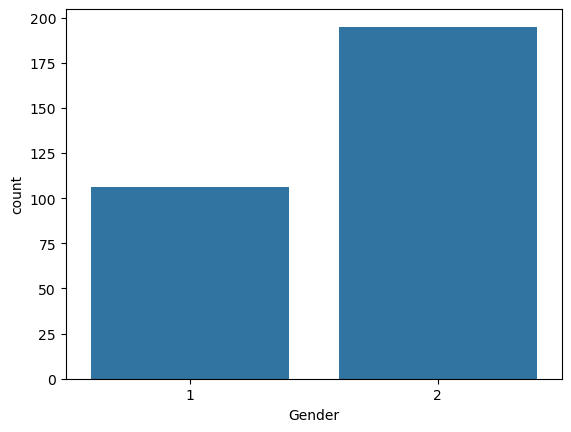

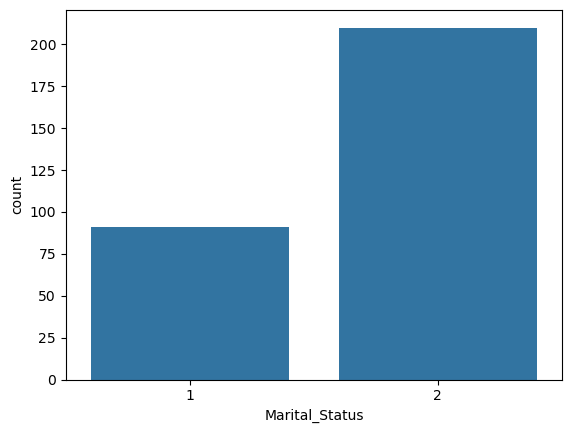

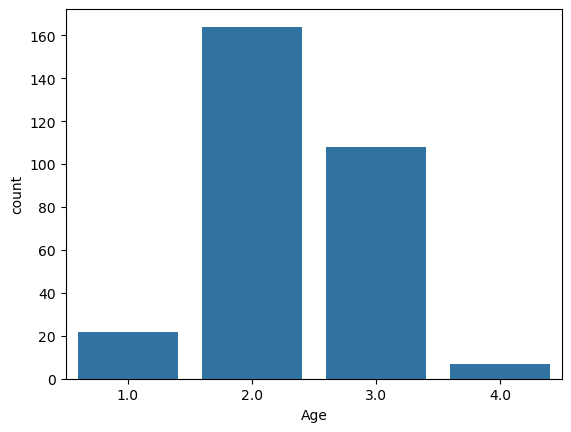

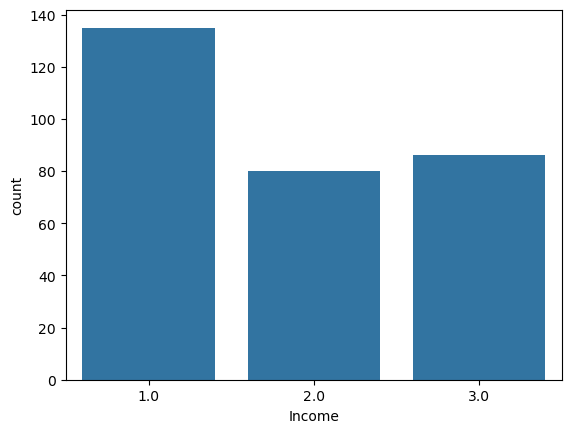

In [62]:
sns.countplot(x='Gender',data=film)
plt.show()
sns.countplot(x='Marital_Status',data=film)
plt.show()
sns.countplot(x='Age',data=film)
plt.show()
sns.countplot(x='Income',data=film)
plt.show()



In [63]:
film

,_rowstate_,Movie,Gender,Marital_Status,Sinage,Parking,Clean,Overall,Age,Income,Hear_About
0,0,Ferris Buellers Day Off,2,1,2.0,2.0,2.0,2.0,3.0,1.0,5
1,0,Ferris Buellers Day Off,2,2,1.0,1.0,1.0,1.0,2.0,1.0,5
2,0,Ferris Buellers Day Off,1,1,2.0,4.0,3.0,2.0,4.0,1.0,5
3,0,Ferris Buellers Day Off,2,1,1.0,3.0,2.0,2.0,4.0,1.0,5
4,0,Ferris Buellers Day Off,2,1,1.0,1.0,1.0,1.0,3.0,3.0,1
...,...,...,...,...,...,...,...,...,...,...,...
325,0,Old School,2,2,1.0,2.0,1.0,1.0,2.0,1.0,1
326,0,Old School,1,1,2.0,2.0,2.0,2.0,3.0,3.0,5
327,0,Old School,2,1,2.0,1.0,1.0,2.0,2.0,2.0,5
328,0,Old School,1,1,1.0,1.0,1.0,1.0,2.0,1.0,3


In [72]:
film['Hear_About'] = film['Hear_About'].str.rsplit(',', n=1).str[0]


<Axes: xlabel='Hear_About', ylabel='count'>

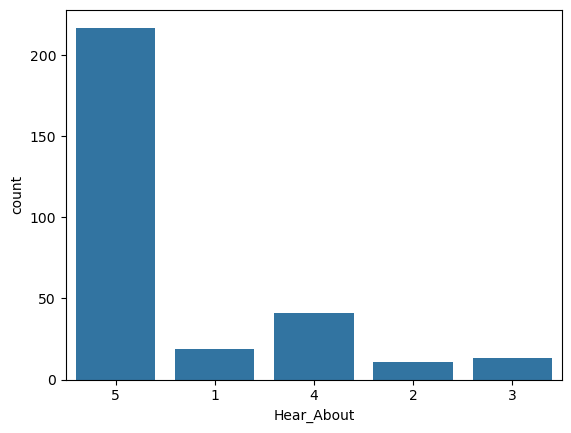

In [ ]:
sns.countplot(x='Hear_About',data=film)
#film series be advertised on Website